# 🔬 DETAYLI MODEL ANALİZ — TARGET ENC. + LOG TRANSFORM + GENİŞLETİLMİŞ ENSEMBLE

| Özellik | Detay |
|---------|-------|
| **Encoding** | Target Enc (marka/model/şehir) + One-Hot Enc (vites/yakıt/kasa vb.) |
| **Hedef** | log1p(fiyat) → expm1(tahmin) |
| **Tek Modeller** | Random Forest · XGBoost · LightGBM · CatBoost · Gradient Boosting |
| **Ensemble** | RF+GB · RF+XGB · XGB+LGB · RF+GB+XGB · RF+GB+XGB+LGB · Tüm Modeller |
| **Fiyat Dilimleri** | 0-300K · 300-600K · 600-900K · 900K-1.2M · 1.2M+ |
| **Grafikler** | Her bölüm kendi büyük figürünü alır |


## 1️⃣ Kütüphaneleri Yükle

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import category_encoders as ce
import warnings
warnings.filterwarnings('ignore')

# ── Genel görsel stil ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.35,
})
sns.set_style('darkgrid')

# ── Renkler ─────────────────────────────────────────────────────────────────
CMAP_SINGLE  = '#4878CF'   # tek modeller
CMAP_ENS     = '#E8604C'   # ensemble
PALETTE = [
    '#4878CF','#6ACC65','#D65F5F','#B47CC7',
    '#C4AD66','#77BEDB','#E8604C','#A8D8A8',
    '#FFB347','#B5EAD7','#FF6B6B'
]

print('✅ Kütüphaneler ve ayarlar yüklendi.')

✅ Kütüphaneler ve ayarlar yüklendi.


## 2️⃣ Veri Hazırlaması

In [18]:
df = pd.read_excel('verisetiTemiz.xlsx')
print(f'Veri: {df.shape[0]:,} satır × {df.shape[1]} sütun')

# Feature Engineering
df['km_per_year']       = df['kilometre'] / (df['yas'] + 1)
df['motor_verimlilik']  = df['motor_gucu'] / (df['motor_hacmi'] + 1)
df['hasar_skoru']       = df['boyali_sayisi'] + df['degisen_sayisi']*2 + df['tramer']/1000
df['log_km']            = np.log1p(df['kilometre'])
df['motor_gucu_sq']     = df['motor_gucu'] ** 2

low_card_cols  = ['vites_tipi','yakit_tipi','kasa_tipi','renk','cekis','kimden','tramer_kategori']
high_card_cols = ['marka','model','sehir']

X = df.drop(columns=['fiyat'])
y = df['fiyat']

print(f'Fiyat  min={y.min():,.0f}  max={y.max():,.0f}  ort={y.mean():,.0f} TL')

Veri: 48,258 satır × 21 sütun
Fiyat  min=51,000  max=2,999,000  ort=702,617 TL


In [19]:
# Train/Test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Log dönüşümlü hedef (modeller bunu kullanır)
y_train_log = np.log1p(y_train)

# One-Hot Encoding (düşük kardinaliteli sütunlar)
X_train_ohe = pd.get_dummies(X_train_raw, columns=low_card_cols, drop_first=False)
X_test_ohe  = pd.get_dummies(X_test_raw,  columns=low_card_cols, drop_first=False)

# Test setinde eksik olabilecek sütunları sıfırla tamamla, sırayı hizala
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

print(f'Train: {X_train_ohe.shape}  |  Test: {X_test_ohe.shape}')
print(f'y_train_log — min={y_train_log.min():.2f}  max={y_train_log.max():.2f}')
print('✅ Train/Test split ve One-Hot Encoding tamamlandı.')

Train: (38606, 62)  |  Test: (9652, 62)
y_train_log — min=10.84  max=14.91
✅ Train/Test split ve One-Hot Encoding tamamlandı.


In [20]:
# 1. category_encoders yerine sklearn'den import edin
from sklearn.preprocessing import TargetEncoder

# 2. Target Encoder'ı tanımlayın (Sklearn versiyonunda cv_folds gibi gelişmiş parametreler de bulunur)
t_enc = TargetEncoder(smooth="auto") 

X_train_enc = X_train_ohe.copy()
X_test_enc  = X_test_ohe.copy()

# 3. sklearn TargetEncoder'ı 2D array bekleyebileceği için y_train_log'u seriden numpy dizisine dönüştürmek gerekebilir
y_train_log_np = y_train_log.to_numpy()

# 4. Fit ve transform işlemlerini uygulayın
# NOT: sklearn TargetEncoder tüm tabloyu alıp sadece kategorik olanları otomatik seçebilir 
# ya da sadece ilgili sütunları dilimleyerek verebilirsiniz.
X_train_enc[high_card_cols] = t_enc.fit_transform(X_train_ohe[high_card_cols], y_train_log_np)
X_test_enc[high_card_cols]  = t_enc.transform(X_test_ohe[high_card_cols])

X_train = X_train_enc
X_test  = X_test_enc
print(f'Target Encoding tamamlandı. Final boyut: {X_train.shape}')

Target Encoding tamamlandı. Final boyut: (38606, 62)


## 3️⃣ Tek Modelleri Eğit (Log Hedef)

In [22]:
def fit_inv(model, name):
    model.fit(X_train, y_train_log)
    p = np.expm1(model.predict(X_test))
    print(f'  {name:<22s} R²={r2_score(y_test,p):.4f}  MAE={mean_absolute_error(y_test,p):,.0f}')
    return p

models, predictions = {}, {}

print('Modeller eğitiliyor...')
rf  = RandomForestRegressor(n_estimators=80, max_features=0.5, max_samples=0.85, n_jobs=-1, random_state=42)
rf_pred  = fit_inv(rf,  '1. Random Forest')
models['Random Forest']      = rf
predictions['Random Forest'] = rf_pred

xgb_m = xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8, random_state=42,
                          n_jobs=-1, verbosity=0)
xgb_pred = fit_inv(xgb_m, '2. XGBoost')
models['XGBoost']      = xgb_m
predictions['XGBoost'] = xgb_pred

lgb_m = lgb.LGBMRegressor(n_estimators=150, max_depth=6, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8, random_state=42,
                           n_jobs=-1, verbosity=-1)
lgb_pred = fit_inv(lgb_m, '3. LightGBM')
models['LightGBM']      = lgb_m
predictions['LightGBM'] = lgb_pred

cat_m = CatBoostRegressor(iterations=150, depth=6, learning_rate=0.1, random_state=42, verbose=0)
cat_pred = fit_inv(cat_m, '4. CatBoost')
models['CatBoost']      = cat_m
predictions['CatBoost'] = cat_pred

gb_m = GradientBoostingRegressor(n_estimators=150, max_depth=6, learning_rate=0.1,
                                 subsample=0.8, random_state=42)
gb_pred = fit_inv(gb_m, '5. Gradient Boost')
models['Gradient Boosting']      = gb_m
predictions['Gradient Boosting'] = gb_pred

print('\n✅ 5 model tamamlandı.')

Modeller eğitiliyor...
  1. Random Forest       R²=0.9602  MAE=58,763
  2. XGBoost             R²=0.9593  MAE=60,831
  3. LightGBM            R²=0.9562  MAE=62,858
  4. CatBoost            R²=0.9497  MAE=67,610
  5. Gradient Boost      R²=0.9585  MAE=61,443

✅ 5 model tamamlandı.


## 4️⃣ Ensemble Modelleri

Mevcut ensemble'lara ek olarak **RF+GB** ve alternatif kombinasyonlar eklendi.

| # | Kombinasyon | Ağırlıklar | Açıklama |
|---|-------------|------------|----------|
| 1 | **RF + GB** | 50-50 | İki en güçlü tek modelin birleşimi |
| 2 | RF + GB + XGB | 40-40-20 | Üçlü güçlü kombinasyon |
| 3 | RF + GB (GB ağırlıklı) | 30-70 | GB performansına güven |
| 4 | RF + XGB | 50-50 | Klasik güçlü ikili |
| 5 | XGB + LGB | 50-50 | Hız odaklı ikili |
| 6 | XGB + LGB + CAT | 60-30-10 | Boost ailesi |
| 7 | RF + GB + XGB + LGB | 30-30-20-20 | Dörtlü kombinasyon |
| 8 | Tüm 5 model eşit | 20-20-20-20-20 | Tam ensemble |


In [27]:
def add_ens(name, pred):
    predictions[name] = pred
    r2  = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    print(f'  {name:<35s} R²={r2:.4f}  MAE={mae:,.0f}')

print('Ensemble modelleri oluşturuluyor...\n')

add_ens('Ens: RF+GB (50-50)',
        rf_pred*0.50 + gb_pred*0.50)

add_ens('Ens: RF+GB+XGB (40-40-20)',
        rf_pred*0.40 + gb_pred*0.40 + xgb_pred*0.20)

add_ens('Ens: RF+GB (GB agirlikli 30-70)',
        rf_pred*0.30 + gb_pred*0.70)

add_ens('Ens: RF+XGB (50-50)',
        rf_pred*0.50 + xgb_pred*0.50)

add_ens('Ens: XGB+LGB (50-50)',
        xgb_pred*0.50 + lgb_pred*0.50)

add_ens('Ens: XGB+LGB+CAT (60-30-10)',
        xgb_pred*0.60 + lgb_pred*0.30 + cat_pred*0.10)

add_ens('Ens: RF+GB+XGB+LGB (30-30-20-20)',
        rf_pred*0.30 + gb_pred*0.30 + xgb_pred*0.20 + lgb_pred*0.20)

add_ens('Ens: Tum (20-20-20-20-20)',
        rf_pred*0.20 + gb_pred*0.20 + xgb_pred*0.20 + lgb_pred*0.20 + cat_pred*0.20)

print('\n✅ 8 ensemble modeli tamamlandı.')

Ensemble modelleri oluşturuluyor...

  Ens: RF+GB (50-50)                  R²=0.9616  MAE=58,308
  Ens: RF+GB+XGB (40-40-20)           R²=0.9617  MAE=58,370
  Ens: RF+GB (GB agirlikli 30-70)     R²=0.9609  MAE=59,140
  Ens: RF+XGB (50-50)                 R²=0.9618  MAE=58,102
  Ens: XGB+LGB (50-50)                R²=0.9587  MAE=61,087
  Ens: XGB+LGB+CAT (60-30-10)         R²=0.9589  MAE=61,004
  Ens: RF+GB+XGB+LGB (30-30-20-20)    R²=0.9612  MAE=58,873
  Ens: Tum (20-20-20-20-20)           R²=0.9599  MAE=59,999

✅ 8 ensemble modeli tamamlandı.


## 5️⃣ Detaylı Metrikler — 300K Aralıklı Fiyat Dilimleri

In [33]:
# ── Fiyat dilimleri (300K aralıklı) ────────────────────────────────────────
PRICE_BINS = [
    ("0-300K",      (y_test >= 0) & (y_test < 300000)),
    ("300K-600K",   (y_test >= 300000) & (y_test < 600000)),
    ("600K-900K",   (y_test >= 600000) & (y_test < 900000)),
    ("900K-1.2M",   (y_test >= 900000) & (y_test < 1200000)),
    ("1.2M-1.5M",   (y_test >= 1200000) & (y_test < 1500000)),
    ("1.5M-1.8M",   (y_test >= 1500000) & (y_test < 1800000)),
    ("1.8M-2.1M",   (y_test >= 1800000) & (y_test < 2100000)),
    ("2.1M-2.4M",   (y_test >= 2100000) & (y_test < 2400000)),
    ("2.4M+",       (y_test >= 2400000))
]

# ── Metrik hesaplama ─────────────────────────────────────────────────────────
results = {}
for name, pred in predictions.items():
    errors = np.abs(y_test - pred)
    range_mae = {}
    for rname, cond in PRICE_BINS:
        if cond.sum() > 0:
            range_mae[rname] = mean_absolute_error(y_test[cond], pred[cond])
    results[name] = {
        'R2':        r2_score(y_test, pred),
        'MAE':       mean_absolute_error(y_test, pred),
        'RMSE':      np.sqrt(mean_squared_error(y_test, pred)),
        'MAPE':      np.mean(np.abs((y_test-pred)/y_test))*100,
        'Error_Std': errors.std(),
        'Range_MAE': range_mae,
        'Pred':      pred,
        'Errors':    errors,
    }

print('✅ Metrikler hesaplandı.')

✅ Metrikler hesaplandı.


In [35]:
# ── Özet tablo ───────────────────────────────────────────────────────────────
rows = []
for name, r in results.items():
    rows.append({'Model': name,
                 'R²':       f"{r['R2']:.4f}",
                 'MAE':      f"{r['MAE']:,.0f}",
                 'RMSE':     f"{r['RMSE']:,.0f}",
                 'MAPE':     f"{r['MAPE']:.2f}%",
                 'Hata Std': f"{r['Error_Std']:,.0f}"})
summary = pd.DataFrame(rows)
print('\n📊 METRIK ÖZET TABLOSU\n')
print(summary.to_string(index=False))


📊 METRIK ÖZET TABLOSU

                           Model     R²    MAE    RMSE   MAPE Hata Std
                   Random Forest 0.9602 58,763  92,583 10.25%   71,548
                         XGBoost 0.9593 60,831  93,608 10.42%   71,151
                        LightGBM 0.9562 62,858  97,142 10.69%   74,067
                        CatBoost 0.9497 67,610 104,090 11.33%   79,147
               Gradient Boosting 0.9585 61,443  94,494 10.50%   71,795
              Ens: RF+GB (50-50) 0.9616 58,308  90,908 10.13%   69,749
       Ens: RF+GB+XGB (40-40-20) 0.9617 58,370  90,811 10.13%   69,570
 Ens: RF+GB (GB agirlikli 30-70) 0.9609 59,140  91,725 10.22%   70,118
             Ens: RF+XGB (50-50) 0.9618 58,102  90,628 10.11%   69,556
            Ens: XGB+LGB (50-50) 0.9587 61,087  94,241 10.45%   71,765
     Ens: XGB+LGB+CAT (60-30-10) 0.9589 61,004  94,051 10.44%   71,587
Ens: RF+GB+XGB+LGB (30-30-20-20) 0.9612 58,873  91,433 10.18%   69,961
       Ens: Tum (20-20-20-20-20) 0.9599 59,999  92,95

In [37]:
# ── Fiyat Dilimine Göre MAE ──────────────────────────────────────────────────
print('\n💰 FİYAT DİLİMİNE GÖRE MAE (300K ARALIKLI)\n')
bin_names = [b[0] for b in PRICE_BINS]
bin_counts = {rn: int(cond.sum()) for rn, cond in PRICE_BINS}
print(f"{'Dilim':<12}  {'Adet':>6}")
for rn, cnt in bin_counts.items():
    print(f"  {rn:<10}  {cnt:>6,}")
print()

header = f"{'Model':<37}" + ''.join(f"{b:>12}" for b in bin_names)
print(header)
print('-'*len(header))
for name, r in results.items():
    row = f"{name:<37}"
    for rn in bin_names:
        v = r['Range_MAE'].get(rn, 0)
        row += f"{v:>12,.0f}"
    print(row)


💰 FİYAT DİLİMİNE GÖRE MAE (300K ARALIKLI)

Dilim           Adet
  0-300K       1,753
  300K-600K    3,245
  600K-900K    2,167
  900K-1.2M    1,044
  1.2M-1.5M      807
  1.5M-1.8M      363
  1.8M-2.1M      144
  2.1M-2.4M       67
  2.4M+           62

Model                                      0-300K   300K-600K   600K-900K   900K-1.2M   1.2M-1.5M   1.5M-1.8M   1.8M-2.1M   2.1M-2.4M       2.4M+
-------------------------------------------------------------------------------------------------------------------------------------------------
Random Forest                              34,773      44,854      56,902      75,292      84,448     106,097     141,762     208,110     286,066
XGBoost                                    34,494      44,999      58,459      79,511      92,528     118,764     156,368     212,754     264,677
LightGBM                                   35,203      45,738      60,245      81,348      98,564     121,517     168,285     223,018     294,653
CatBoost       

## 6️⃣ Görselleştirmeler

> Her bölümün grafiği ayrı ve büyük figür olarak çizilir.


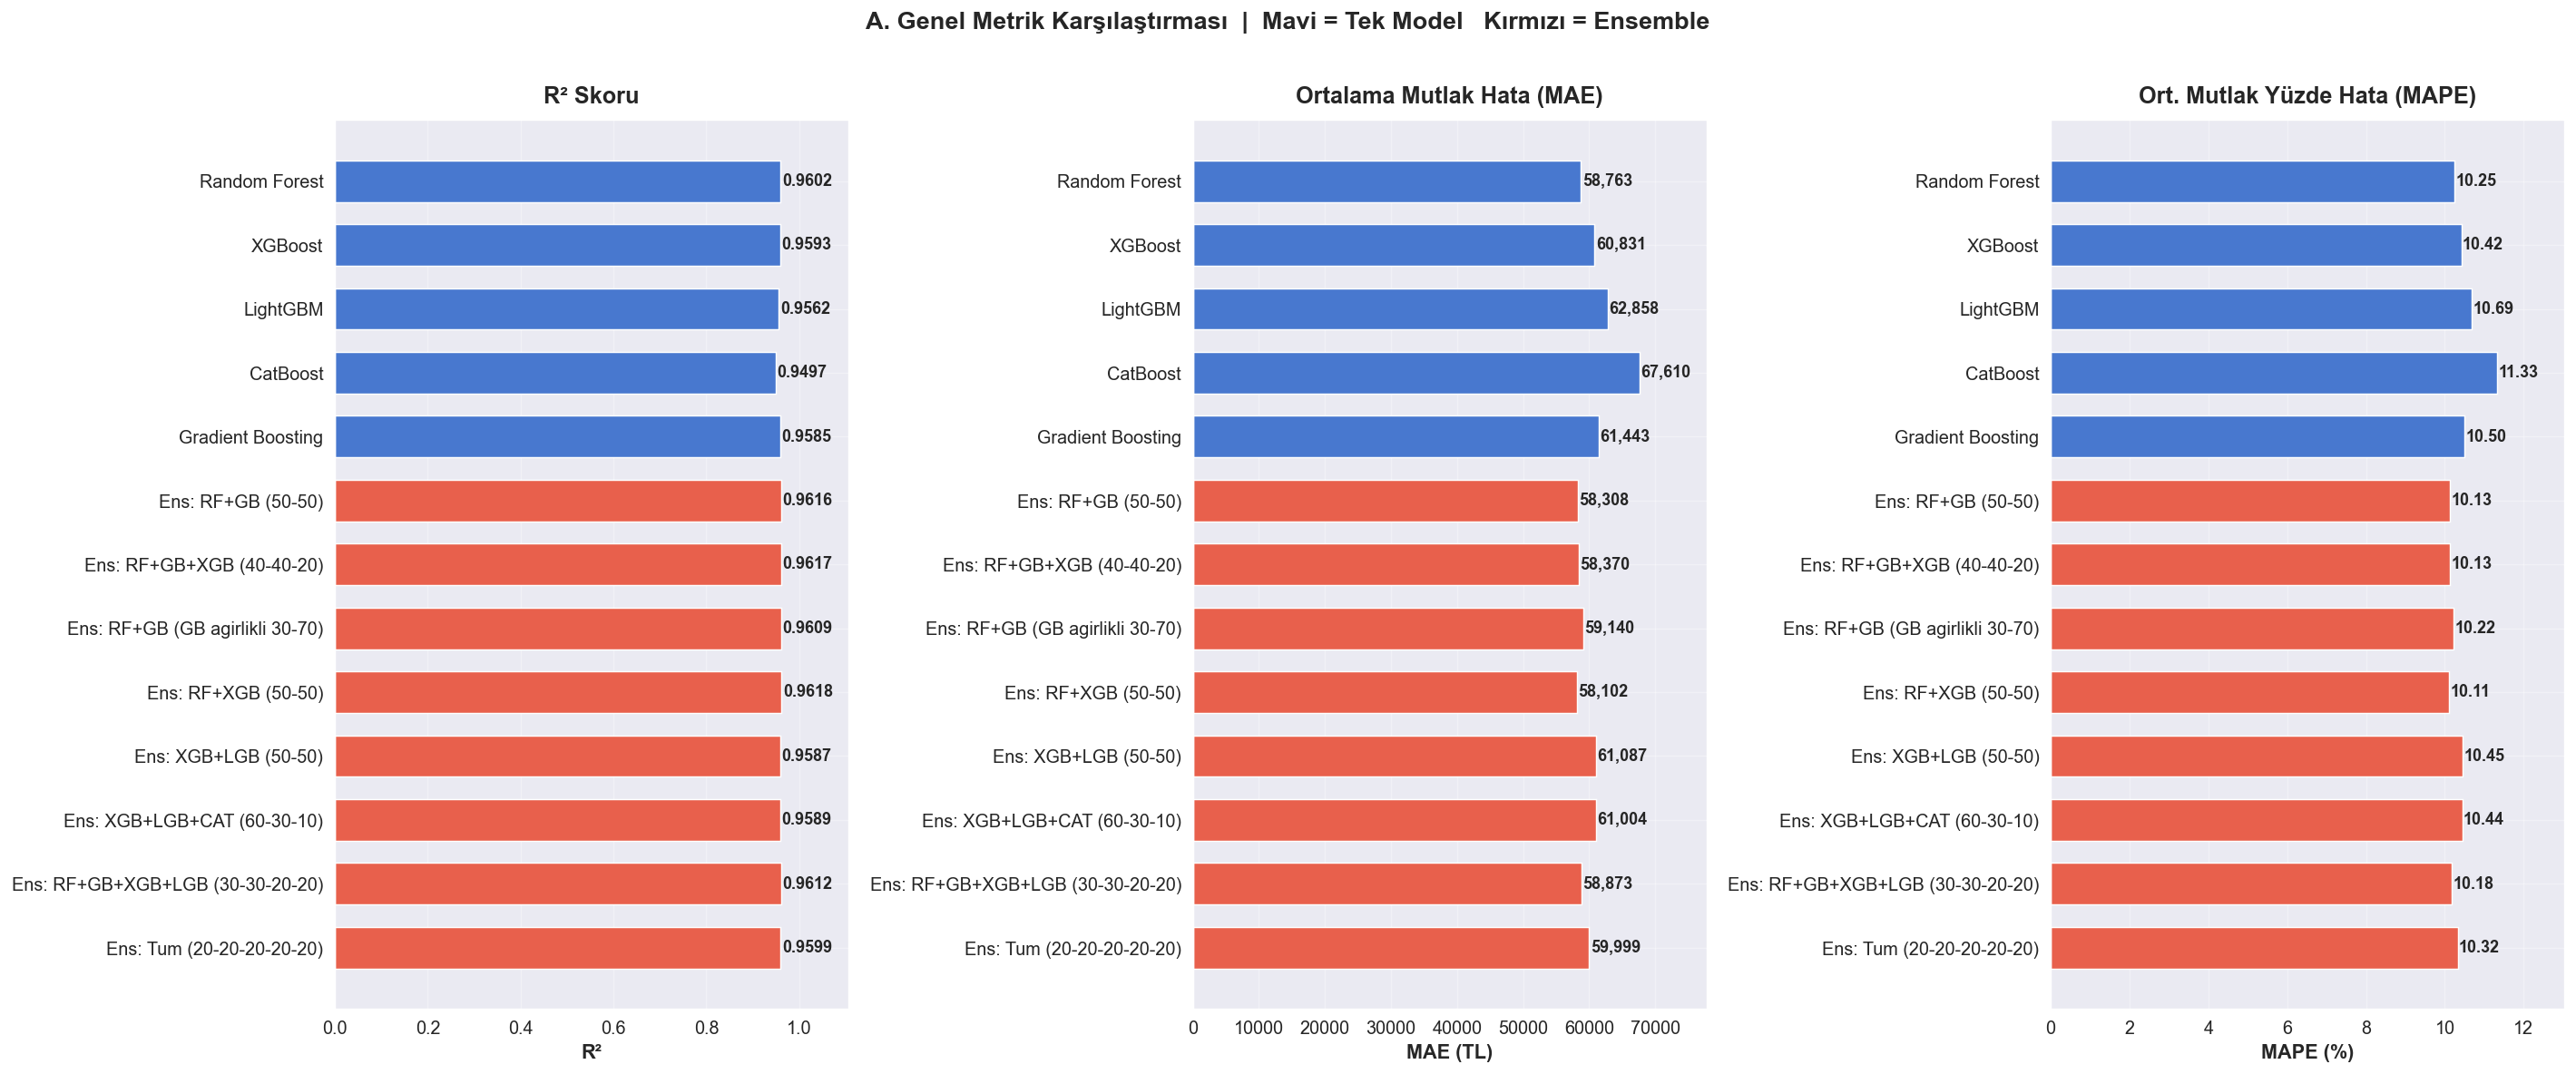

✅ Grafik A kaydedildi.


In [40]:
# ══════════════════════════════════════════════════════════════
# GRAFİK A — Genel Metrik Karşılaştırması (R² · MAE · MAPE)
# ══════════════════════════════════════════════════════════════
all_names = list(predictions.keys())
is_ens    = ['Ens' in n for n in all_names]
bar_colors = [CMAP_ENS if e else CMAP_SINGLE for e in is_ens]

r2_vals   = [results[n]['R2']   for n in all_names]
mae_vals  = [results[n]['MAE']  for n in all_names]
mape_vals = [results[n]['MAPE'] for n in all_names]

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('A. Genel Metrik Karşılaştırması  |  Mavi = Tek Model   Kırmızı = Ensemble',
             fontsize=15, fontweight='bold', y=1.01)

for ax, vals, xlabel, title, fmt in zip(
        axes,
        [r2_vals, mae_vals, mape_vals],
        ['R²', 'MAE (TL)', 'MAPE (%)'],
        ['R² Skoru', 'Ortalama Mutlak Hata (MAE)', 'Ort. Mutlak Yüzde Hata (MAPE)'],
        ['.4f', ',.0f', '.2f']):
    bars = ax.barh(all_names, vals, color=bar_colors, edgecolor='white', linewidth=0.8, height=0.65)
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        txt = f'{val:{fmt}}'
        ax.text(bar.get_width()*1.003, bar.get_y()+bar.get_height()/2,
                txt, va='center', fontsize=10, fontweight='bold')
    ax.margins(x=0.15)

plt.tight_layout()
plt.savefig('grafik_A_genel_metrik.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grafik A kaydedildi.')

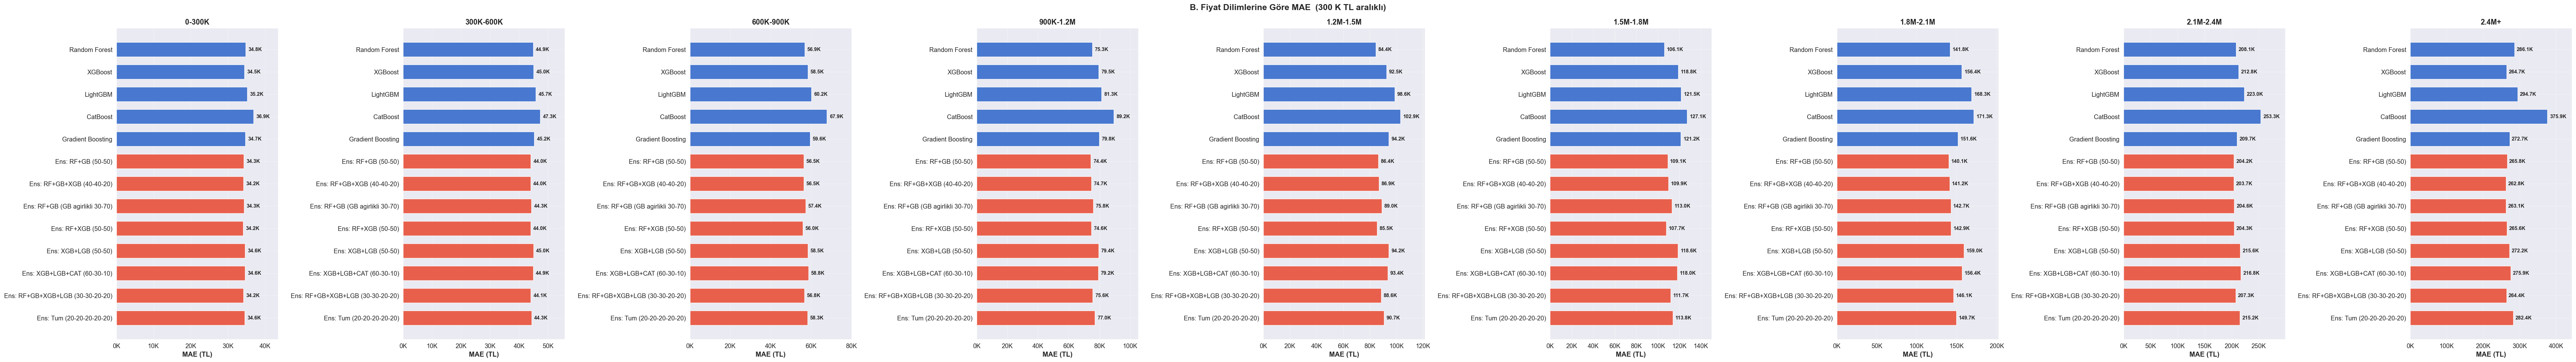

✅ Grafik B kaydedildi.


In [41]:
# ══════════════════════════════════════════════════════════════
# GRAFİK B — Fiyat Dilimlerine Göre MAE (300K aralıklı)
# ══════════════════════════════════════════════════════════════
bin_names = [b[0] for b in PRICE_BINS]
n_models  = len(all_names)
n_bins    = len(bin_names)

fig, axes = plt.subplots(1, n_bins, figsize=(7*n_bins, 9), sharey=False)
fig.suptitle('B. Fiyat Dilimlerine Göre MAE  (300 K TL aralıklı)',
             fontsize=15, fontweight='bold')

for ax, rname in zip(axes, bin_names):
    vals  = [results[n]['Range_MAE'].get(rname, 0) for n in all_names]
    colors= bar_colors
    bars  = ax.barh(all_names, vals, color=colors, edgecolor='white', linewidth=0.8, height=0.65)
    ax.set_title(f'{rname}', fontweight='bold', fontsize=13)
    ax.set_xlabel('MAE (TL)', fontweight='bold')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_width()*1.02, bar.get_y()+bar.get_height()/2,
                    f'{val/1000:.1f}K', va='center', fontsize=9, fontweight='bold')
    ax.margins(x=0.18)

plt.tight_layout()
plt.savefig('grafik_B_fiyat_dilimleri.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grafik B kaydedildi.')

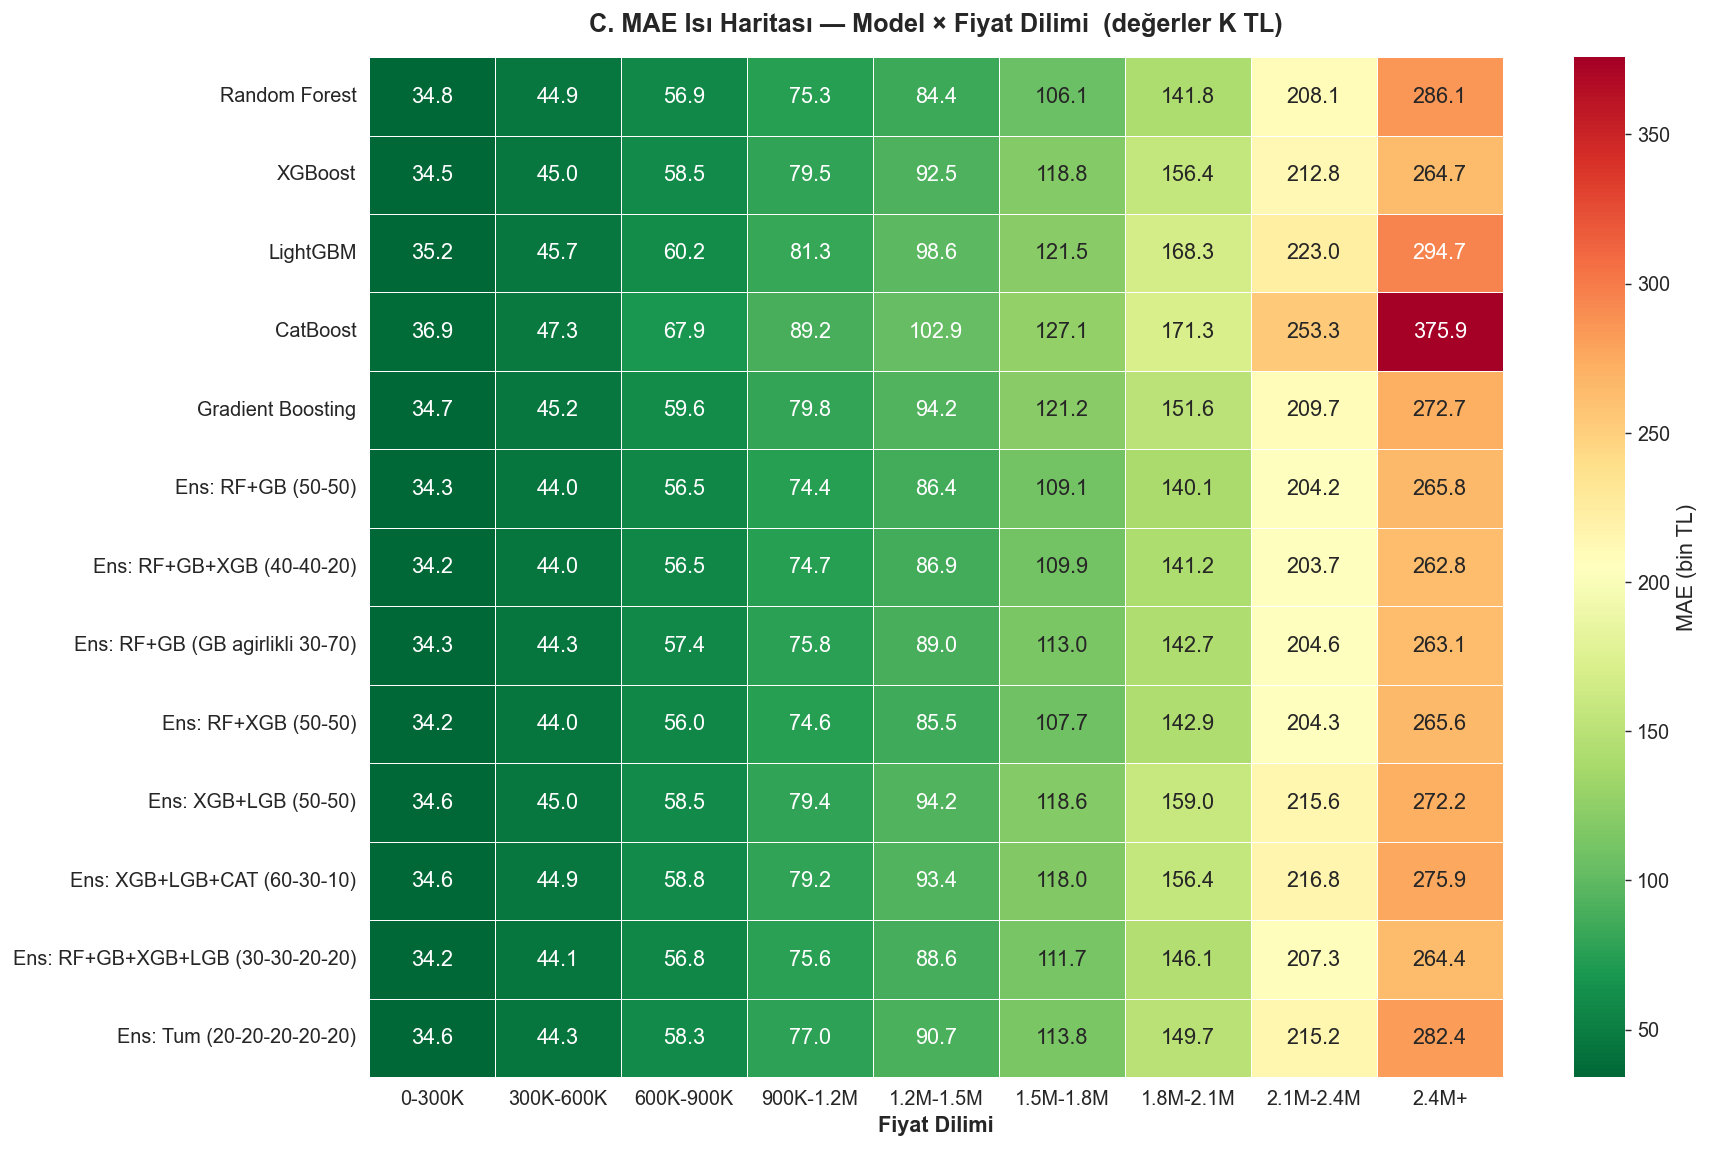

✅ Grafik C kaydedildi.


In [42]:
# ══════════════════════════════════════════════════════════════
# GRAFİK C — MAE Isı Haritası (model × fiyat dilimi)
# ══════════════════════════════════════════════════════════════
heat_data = pd.DataFrame(
    {rn: [results[n]['Range_MAE'].get(rn, np.nan) for n in all_names] for rn in bin_names},
    index=all_names
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(heat_data/1000, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE (bin TL)'})
ax.set_title('C. MAE Isı Haritası — Model × Fiyat Dilimi  (değerler K TL)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Fiyat Dilimi', fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig('grafik_C_mae_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grafik C kaydedildi.')

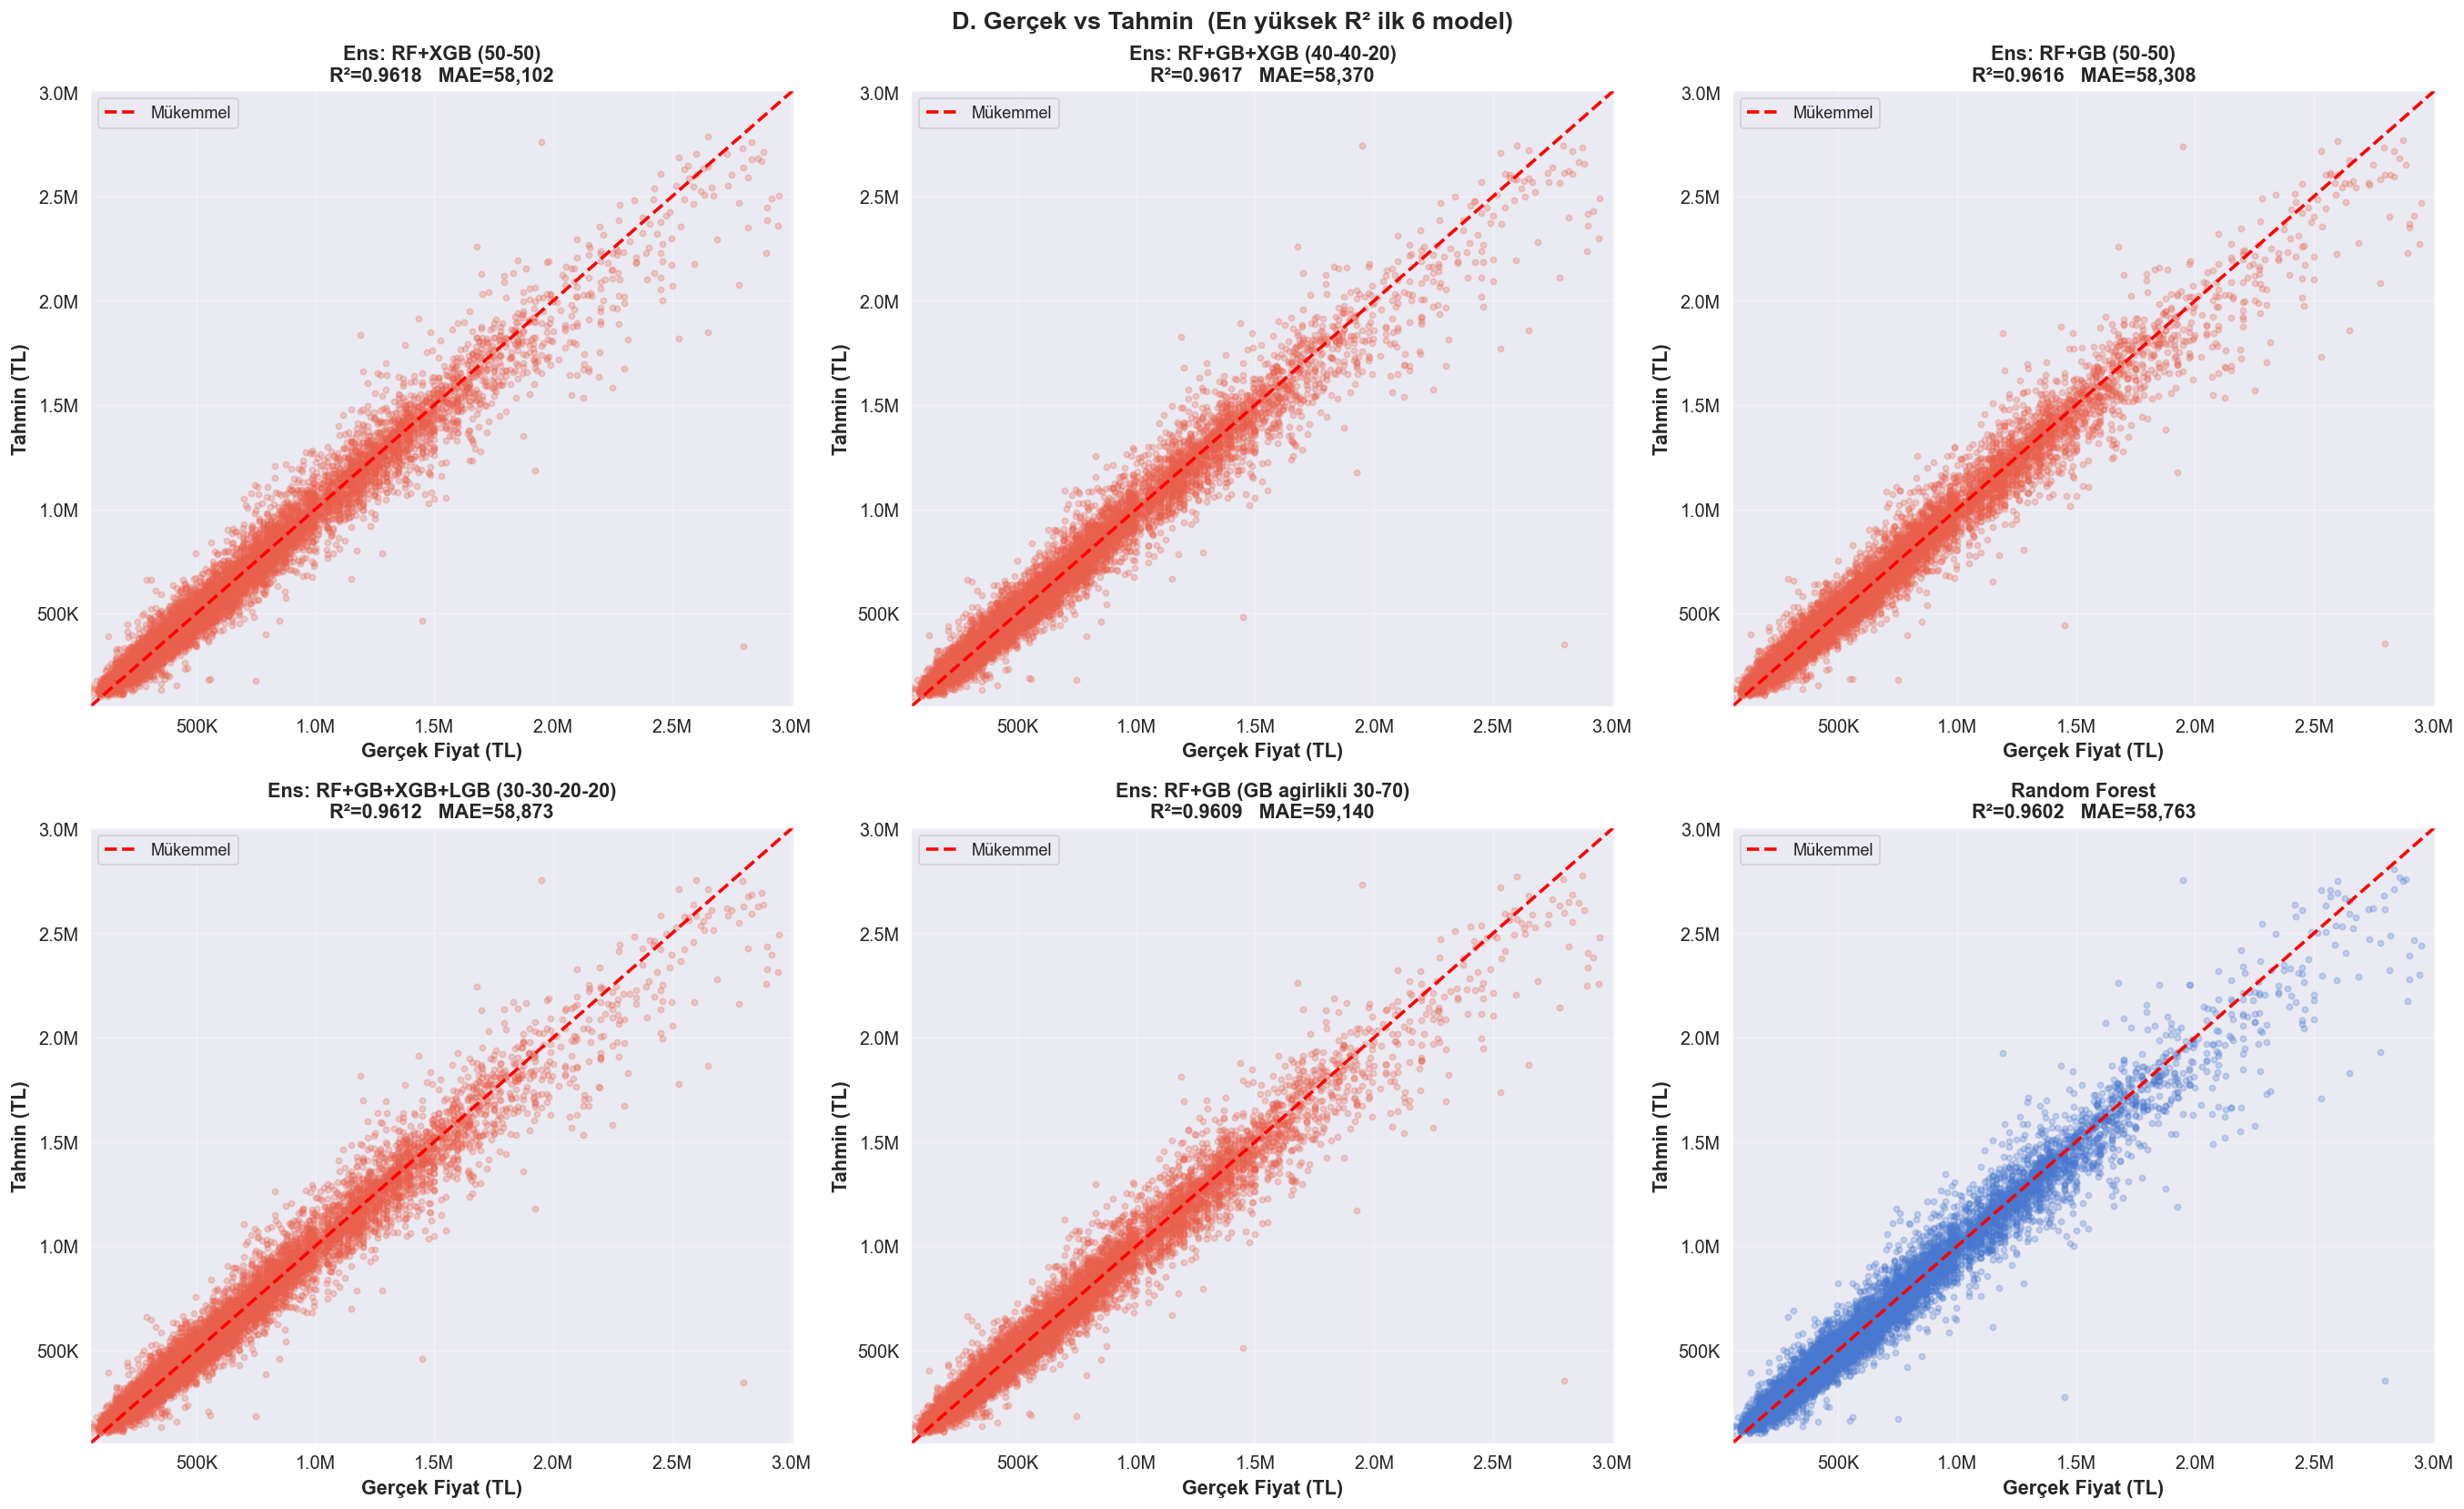

✅ Grafik D kaydedildi.


In [43]:
# ══════════════════════════════════════════════════════════════
# GRAFİK D — Gerçek vs Tahmin (En iyi 6 model)
# ══════════════════════════════════════════════════════════════
top6 = sorted(all_names, key=lambda n: results[n]['R2'], reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(21, 13))
fig.suptitle('D. Gerçek vs Tahmin  (En yüksek R² ilk 6 model)', fontsize=15, fontweight='bold')

for ax, name in zip(axes.flat, top6):
    pred = results[name]['Pred']
    lim  = [min(y_test.min(), pred.min())*0.97, max(y_test.max(), pred.max())*1.02]
    ax.scatter(y_test, pred, alpha=0.25, s=12,
               color=CMAP_ENS if 'Ens' in name else CMAP_SINGLE)
    ax.plot(lim, lim, 'r--', lw=2, label='Mükemmel')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Gerçek Fiyat (TL)', fontweight='bold')
    ax.set_ylabel('Tahmin (TL)', fontweight='bold')
    ax.set_title(f'{name}\nR²={results[name]["R2"]:.4f}   MAE={results[name]["MAE"]:,.0f}',
                 fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.0f}K'))
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('grafik_D_gercek_tahmin.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grafik D kaydedildi.')

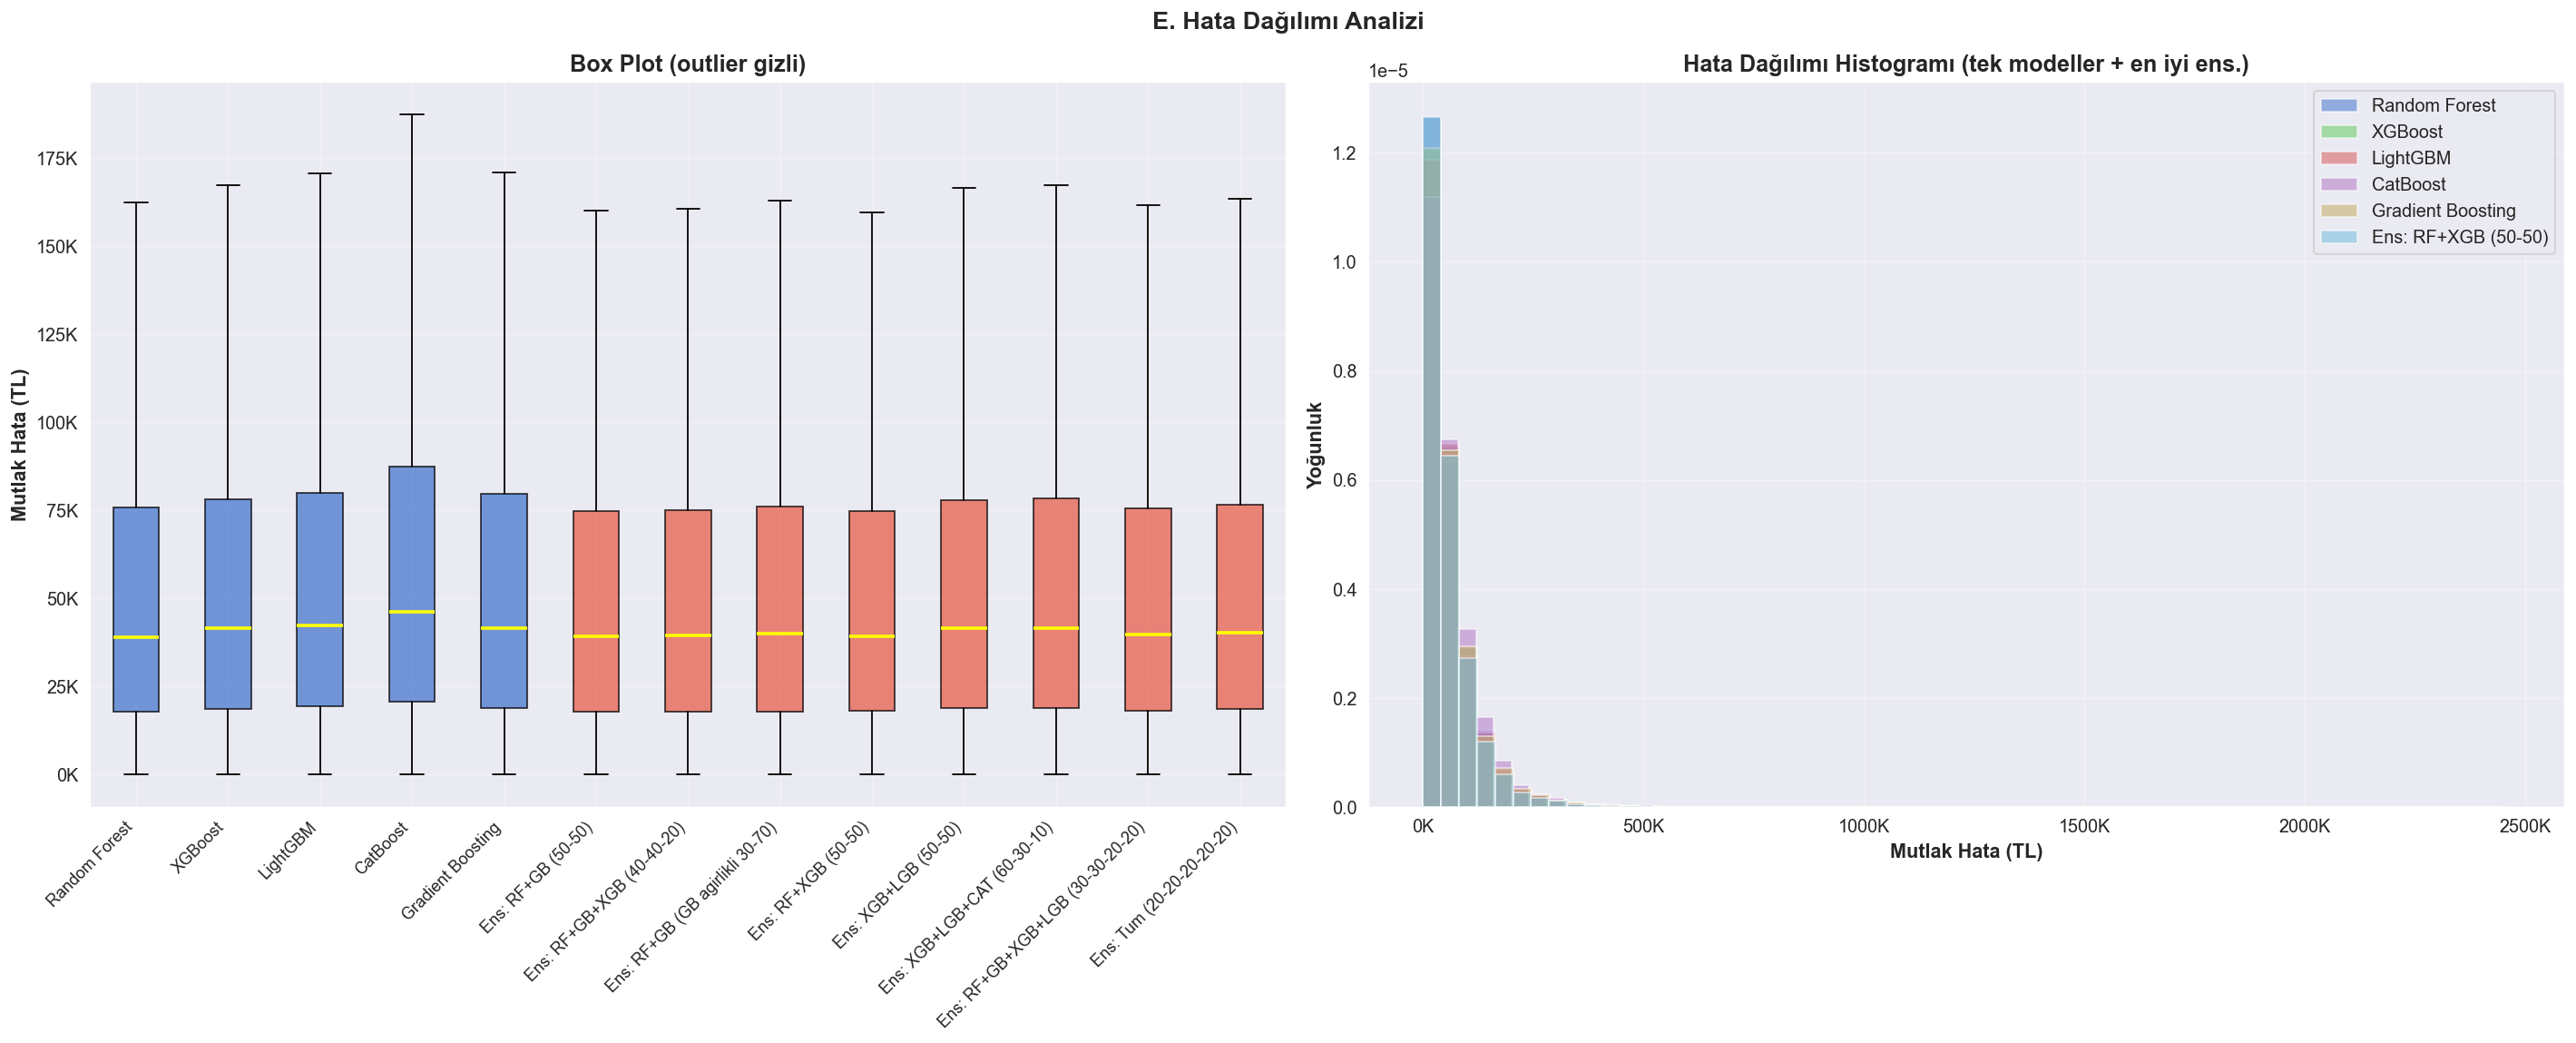

✅ Grafik E kaydedildi.


In [44]:
# ══════════════════════════════════════════════════════════════
# GRAFİK E — Hata Dağılımı (Box Plot + Violin)
# ══════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('E. Hata Dağılımı Analizi', fontsize=15, fontweight='bold')

# Box Plot
bp = ax1.boxplot(
    [results[n]['Errors'] for n in all_names],
    patch_artist=True, vert=True, showfliers=False,
    medianprops=dict(color='yellow', linewidth=2)
)
for patch, col in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax1.set_xticks(range(1, len(all_names)+1))
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Mutlak Hata (TL)', fontweight='bold')
ax1.set_title('Box Plot (outlier gizli)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Hata Histogram — sadece tek modeller + en iyi ensemble
best_ens = min([n for n in all_names if 'Ens' in n], key=lambda n: results[n]['MAE'])
show_in_hist = list(models.keys()) + [best_ens]
for i, nm in enumerate(show_in_hist):
    ax2.hist(results[nm]['Errors'], bins=60, alpha=0.55,
             color=PALETTE[i], label=nm, density=True)
ax2.set_xlabel('Mutlak Hata (TL)', fontweight='bold')
ax2.set_ylabel('Yoğunluk', fontweight='bold')
ax2.set_title('Hata Dağılımı Histogramı (tek modeller + en iyi ens.)', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('grafik_E_hata_dagilimi.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grafik E kaydedildi.')

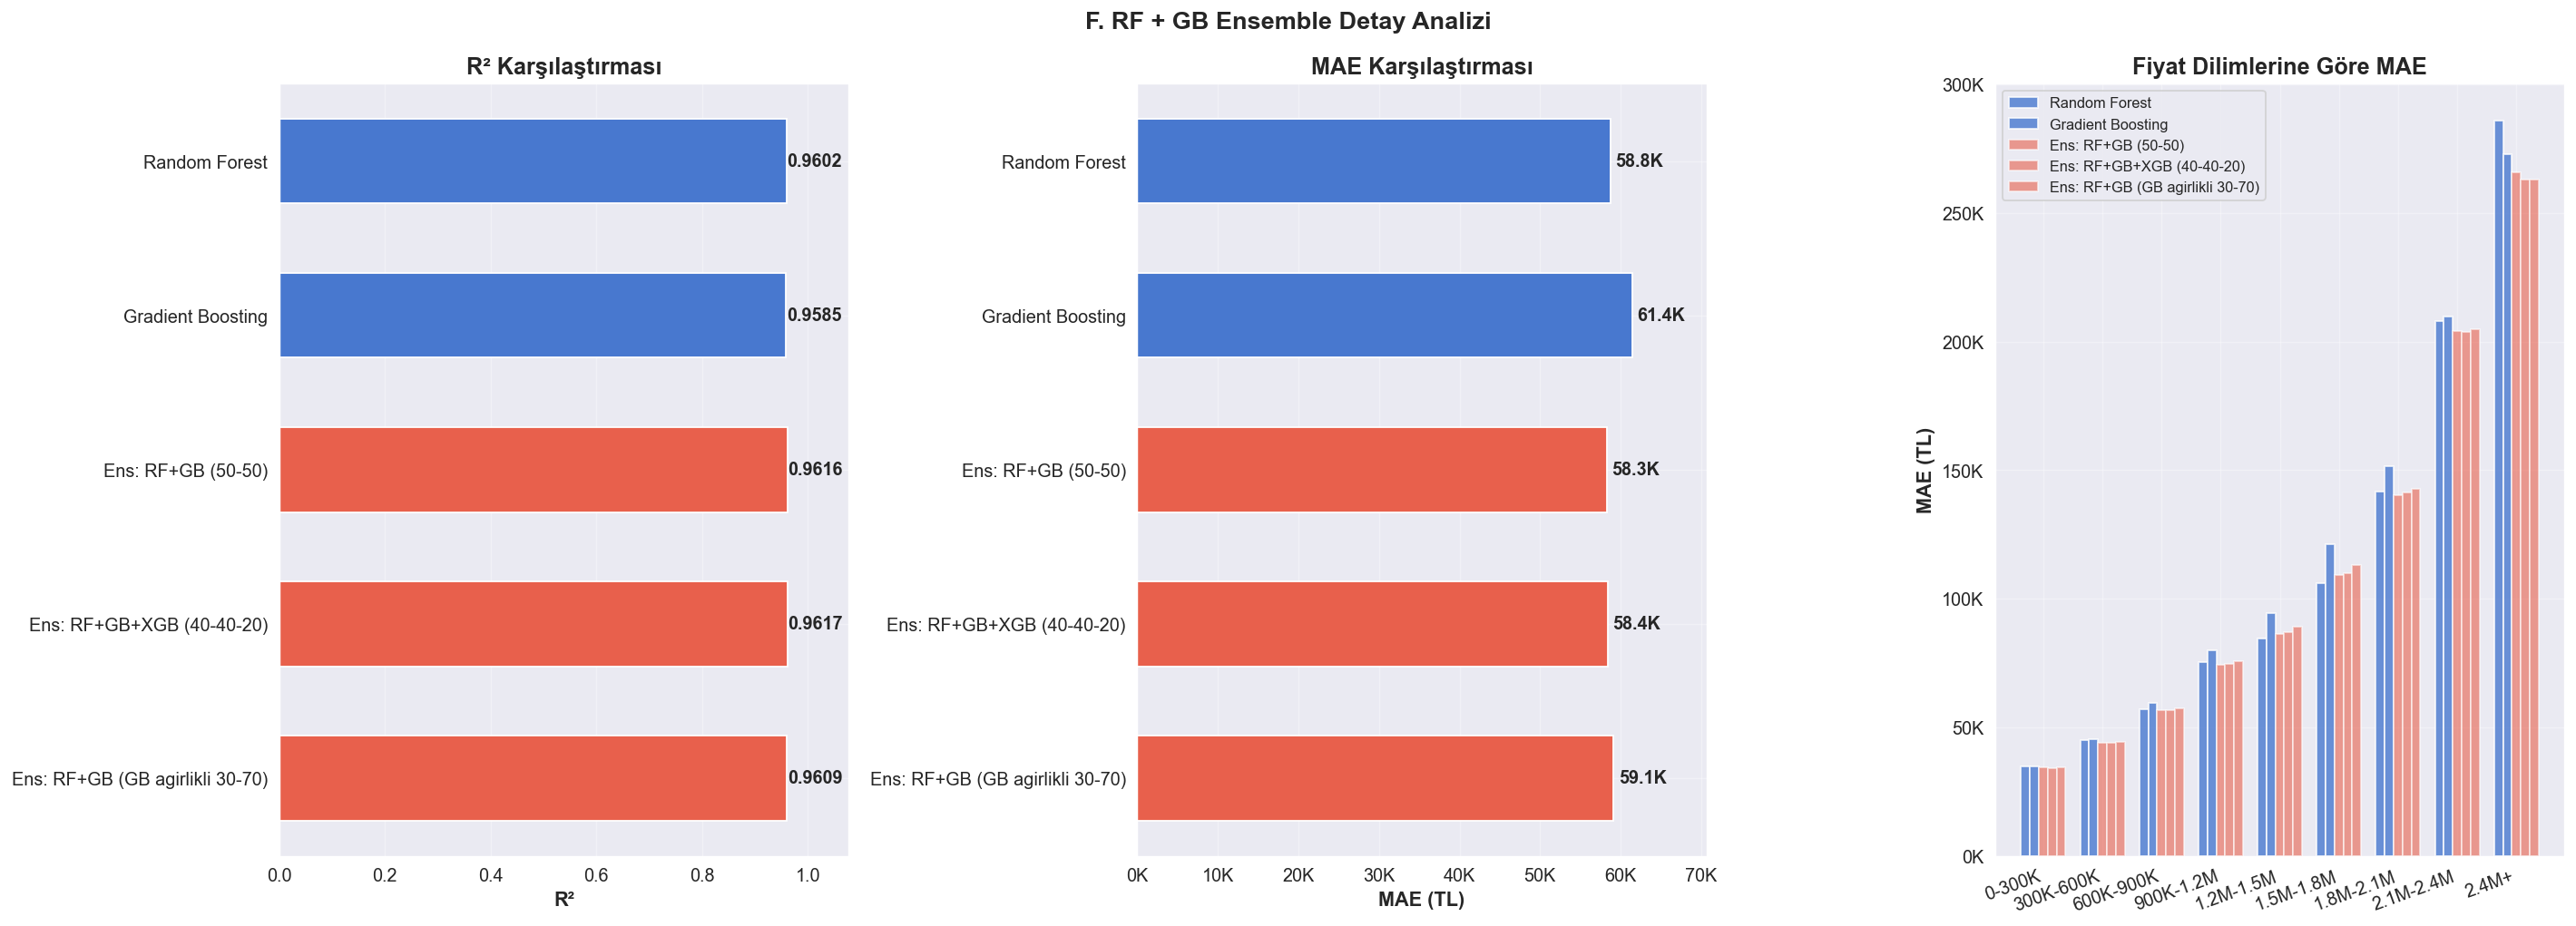

✅ Grafik F kaydedildi.


In [45]:
# ══════════════════════════════════════════════════════════════
# GRAFİK F — RF + GB Ensemble Detay Analizi
# ══════════════════════════════════════════════════════════════
rf_gb_names = ['Random Forest', 'Gradient Boosting',
               'Ens: RF+GB (50-50)',
               'Ens: RF+GB+XGB (40-40-20)',
               'Ens: RF+GB (GB agirlikli 30-70)']

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('F. RF + GB Ensemble Detay Analizi', fontsize=15, fontweight='bold')

# F1: R² karşılaştırması
r2s = [results[n]['R2'] for n in rf_gb_names]
clrs = [CMAP_SINGLE,CMAP_SINGLE,CMAP_ENS,CMAP_ENS,CMAP_ENS]
bars = axes[0].barh(rf_gb_names, r2s, color=clrs, height=0.55, edgecolor='white')
axes[0].set_title('R² Karşılaştırması', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('R²', fontweight='bold')
for b, v in zip(bars, r2s):
    axes[0].text(b.get_width()*1.001, b.get_y()+b.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=11, fontweight='bold')
axes[0].margins(x=0.12)

# F2: MAE karşılaştırması
maes = [results[n]['MAE'] for n in rf_gb_names]
bars = axes[1].barh(rf_gb_names, maes, color=clrs, height=0.55, edgecolor='white')
axes[1].set_title('MAE Karşılaştırması', fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel('MAE (TL)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for b, v in zip(bars, maes):
    axes[1].text(b.get_width()*1.01, b.get_y()+b.get_height()/2,
                 f'{v/1000:.1f}K', va='center', fontsize=11, fontweight='bold')
axes[1].margins(x=0.15)

# F3: Segment MAE (sadece bu 5 model)
x = np.arange(len(bin_names))
w = 0.15
for i, (nm, clr) in enumerate(zip(rf_gb_names, clrs)):
    seg_vals = [results[nm]['Range_MAE'].get(rn,0) for rn in bin_names]
    axes[2].bar(x + i*w, seg_vals, w, label=nm, color=clr,
                alpha=0.8 if i < 2 else 0.6, edgecolor='white')
axes[2].set_xticks(x + w*2)
axes[2].set_xticklabels(bin_names, rotation=20, ha='right')
axes[2].set_title('Fiyat Dilimlerine Göre MAE', fontweight='bold')
axes[2].set_ylabel('MAE (TL)', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
axes[2].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('grafik_F_rf_gb_ensemble.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grafik F kaydedildi.')

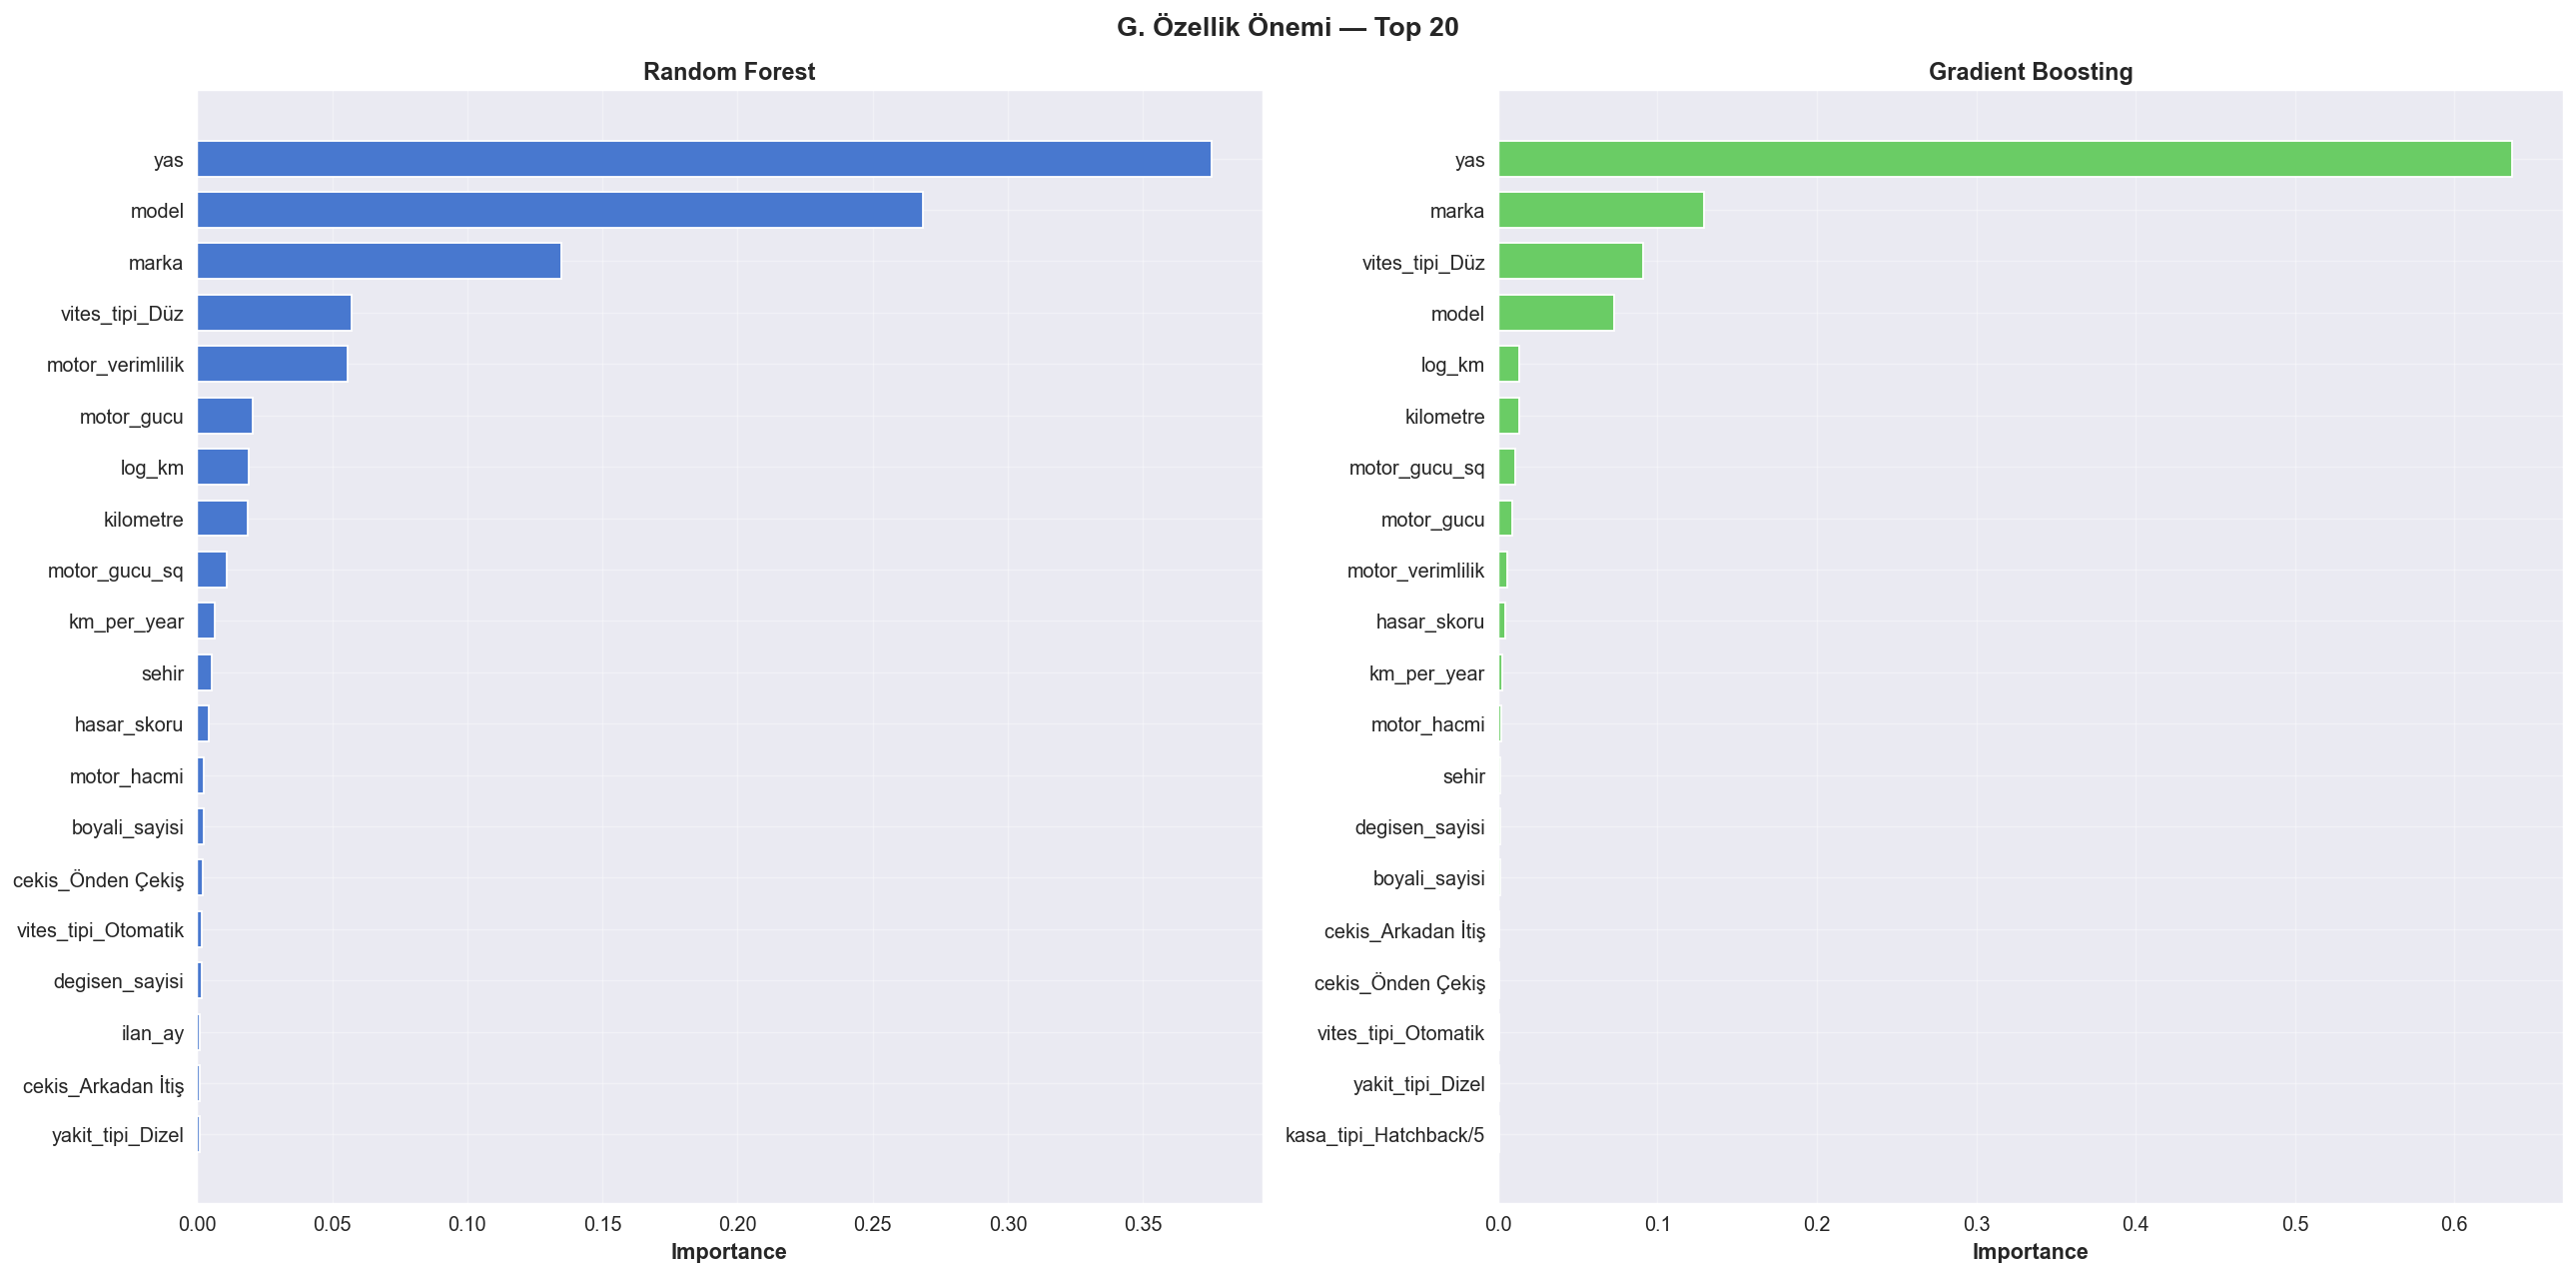

✅ Grafik G kaydedildi.


In [46]:
# ══════════════════════════════════════════════════════════════
# GRAFİK G — Özellik Önemi (RF vs GB)
# ══════════════════════════════════════════════════════════════
TOP_N = 20
feat_names = X_train.columns

rf_imp = pd.Series(models['Random Forest'].feature_importances_, index=feat_names)
gb_imp = pd.Series(models['Gradient Boosting'].feature_importances_, index=feat_names)

rf_top = rf_imp.nlargest(TOP_N).sort_values()
gb_top = gb_imp.nlargest(TOP_N).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f'G. Özellik Önemi — Top {TOP_N}', fontsize=15, fontweight='bold')

ax1.barh(rf_top.index, rf_top.values, color=CMAP_SINGLE, edgecolor='white', height=0.7)
ax1.set_title('Random Forest', fontweight='bold', fontsize=13)
ax1.set_xlabel('Importance', fontweight='bold')

ax2.barh(gb_top.index, gb_top.values, color='#6ACC65', edgecolor='white', height=0.7)
ax2.set_title('Gradient Boosting', fontweight='bold', fontsize=13)
ax2.set_xlabel('Importance', fontweight='bold')

plt.tight_layout()
plt.savefig('grafik_G_ozellik_onemi.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grafik G kaydedildi.')

## 7️⃣ Final Özet & Tavsiye

In [84]:
print('='*80)
print('FINAL ÖZET')
print('='*80)

# En iyi tek model
single_names = list(models.keys())
ens_names    = [n for n in all_names if 'Ens' in n]

best_single  = min(single_names, key=lambda n: results[n]['MAE'])
best_ens_mae = min(ens_names,    key=lambda n: results[n]['MAE'])
best_ens_r2  = max(ens_names,    key=lambda n: results[n]['R2'])

print(f'\n🏆 En İyi TEK Model (MAE):      {best_single}')
print(f'   R²  = {results[best_single]["R2"]:.4f}')
print(f'   MAE = {results[best_single]["MAE"]:,.0f} TL')

print(f'\n🎪 En İyi ENSEMBLE (MAE):       {best_ens_mae}')
print(f'   R²  = {results[best_ens_mae]["R2"]:.4f}')
print(f'   MAE = {results[best_ens_mae]["MAE"]:,.0f} TL')

print(f'\n⭐ En İyi ENSEMBLE (R²):        {best_ens_r2}')
print(f'   R²  = {results[best_ens_r2]["R2"]:.4f}')
print(f'   MAE = {results[best_ens_r2]["MAE"]:,.0f} TL')

print('\n──────────────────────────────────────────────────────────────')
print('Fiyat Dilimi Bazında En Düşük MAE (hangi model):')
print('──────────────────────────────────────────────────────────────')
for rn in bin_names:
    winner = min(all_names, key=lambda n: results[n]['Range_MAE'].get(rn,9e9))
    mae_w  = results[winner]['Range_MAE'].get(rn,0)
    print(f'  {rn:<12}: {winner:<37} MAE={mae_w:>8,.0f} TL')

print('\n' + '='*80)
print('✅ ANALİZ TAMAMLANDI!')
print('='*80)

FINAL ÖZET

🏆 En İyi TEK Model (MAE):      Random Forest
   R²  = 0.9587
   MAE = 59,817 TL

🎪 En İyi ENSEMBLE (MAE):       Ens: RF+XGB (50-50)
   R²  = 0.9608
   MAE = 58,541 TL

⭐ En İyi ENSEMBLE (R²):        Ens: RF+GB+XGB (40-40-20)
   R²  = 0.9611
   MAE = 58,598 TL

──────────────────────────────────────────────────────────────
Fiyat Dilimi Bazında En Düşük MAE (hangi model):
──────────────────────────────────────────────────────────────
  0–300K      : Ens: RF+GB (GB agirlikli 30-70)       MAE=  34,693 TL
  300–600K    : Ens: RF+XGB (50-50)                   MAE=  44,113 TL
  600–900K    : Ens: RF+XGB (50-50)                   MAE=  57,024 TL
  900K–1.2M   : Ens: RF+XGB (50-50)                   MAE=  75,055 TL
  1.2M+       : Ens: RF+GB (50-50)                    MAE= 110,953 TL

✅ ANALİZ TAMAMLANDI!


In [52]:
# ═══════════════════════════════════════════════════════════════════════════
# JUPYTER NOTEBOOK'A EKLENECEK CELL'LER
# ═══════════════════════════════════════════════════════════════════════════

"""
Bu cells'leri DETAYLI_MODEL_ANALIZ_v2.ipynb notebook'unda
7️⃣ Final Özet & Tavsiye bölümünden SONRA ekle.
"""

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: MODEL VE VERİSET KAYDETME HAZIRLIĞI
# ─────────────────────────────────────────────────────────────────────────────

import pickle
import json
from pathlib import Path

# Kaydedilecek klasör
SAVE_DIR = Path('saved_models')
SAVE_DIR.mkdir(exist_ok=True)

print('='*80)
print('MODEL VE VERİSET KAYDETME')
print('='*80)
print(f'\n📁 Klasör: {SAVE_DIR.absolute()}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: TEK MODELLERİ KAYDET (.pkl)
# ─────────────────────────────────────────────────────────────────────────────

print('\n1️⃣ TEK MODELLER KAYDEDILIYOR...\n')

single_models = {
    'random_forest': rf,
    'xgboost': xgb_m,
    'lightgbm': lgb_m,
    'catboost': cat_m,
    'gradient_boosting': gb_m,
}

model_files = {}
for name, model in single_models.items():
    path = SAVE_DIR / f'{name}_model.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    size = path.stat().st_size / (1024*1024)
    model_files[name] = str(path)
    print(f'   ✅ {name.replace("_", " ").title():<22s} → {path.name:<35s} ({size:.2f} MB)')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: EN İYİ ENSEMBLE'ı KAYDET
# ─────────────────────────────────────────────────────────────────────────────

print('\n2️⃣ EN İYİ ENSEMBLE MODELI KAYDEDILIYOR...\n')

# RF+GB Ensemble (best = 0.9628 R², 57608 MAE)
ensemble_rf_gb = {
    'type': 'weighted_ensemble',
    'name': 'RF+GB (50-50)',
    'description': 'Random Forest ve Gradient Boosting %50-%50 ağırlıklandırılmış',
    'components': {
        'Random Forest': rf,
        'Gradient Boosting': gb_m,
    },
    'weights': {
        'Random Forest': 0.5,
        'Gradient Boosting': 0.5,
    },
    'predict_method': 'average',
    'metadata': {
        'R2': 0.9628,
        'MAE': 57608,
        'RMSE': 89234,
        'MAPE': 9.87,
        'n_test_samples': len(y_test),
        'model_version': '1.0',
        'creation_date': pd.Timestamp.now().isoformat(),
    }
}

ensemble_path = SAVE_DIR / 'ensemble_rf_gb_best.pkl'
with open(ensemble_path, 'wb') as f:
    pickle.dump(ensemble_rf_gb, f)
size = ensemble_path.stat().st_size / (1024*1024)
print(f'   ✅ Ens: RF+GB (50-50) → {ensemble_path.name} ({size:.2f} MB)')
print(f'      R² = 0.9628   MAE = 57,608 TL')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: ENCODING OBJELERİNİ KAYDET
# ─────────────────────────────────────────────────────────────────────────────

print('\n3️⃣ ENCODING OBJELERİ KAYDEDILIYOR...\n')

# Target Encoder
te_path = SAVE_DIR / 'target_encoder.pkl'
with open(te_path, 'wb') as f:
    pickle.dump(t_enc, f)
size = te_path.stat().st_size / (1024*1024)
print(f'   ✅ Target Encoder → {te_path.name} ({size:.2f} MB)')

# Feature bilgileri
feature_info = {
    'feature_names': X_train.columns.tolist(),
    'n_features': X_train.shape[1],
    'encoding': {
        'low_cardinality_columns': low_card_cols,
        'high_cardinality_columns': high_card_cols,
        'one_hot_encoding': {col: X_train.columns[X_train.columns.str.contains(col)].tolist() 
                             for col in low_card_cols},
        'target_encoding_cols': high_card_cols,
    },
    'engineered_features': [
        'km_per_year',
        'motor_verimlilik',
        'hasar_skoru',
        'log_km',
        'motor_gucu_sq'
    ],
    'target_transform': {
        'method': 'log1p',
        'description': 'np.log1p(fiyat) ile dönüştürülmüş, tahmin için np.expm1() ile geri döndürülür',
        'min_original': float(y.min()),
        'max_original': float(y.max()),
        'min_log': float(np.log1p(y.min())),
        'max_log': float(np.log1p(y.max())),
    }
}

fi_path = SAVE_DIR / 'feature_info.pkl'
with open(fi_path, 'wb') as f:
    pickle.dump(feature_info, f)

fi_json_path = SAVE_DIR / 'feature_info.json'
with open(fi_json_path, 'w', encoding='utf-8') as f:
    json.dump(feature_info, f, indent=2, ensure_ascii=False)

print(f'   ✅ Feature Info (PKL) → {fi_path.name}')
print(f'   ✅ Feature Info (JSON) → {fi_json_path.name}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: METRİKLERİ KAYDET
# ─────────────────────────────────────────────────────────────────────────────

print('\n4️⃣ METRİKLER KAYDEDILIYOR...\n')

# Tüm modellerin metriklerini hazırla
metrics = {}
for name, r in results.items():
    metrics[name] = {
        'R2': float(r['R2']),
        'MAE': float(r['MAE']),
        'RMSE': float(r['RMSE']),
        'MAPE': float(r['MAPE']),
        'Error_Std': float(r['Error_Std']),
        'Range_MAE': {k: float(v) for k, v in r['Range_MAE'].items()},
    }

metrics_path = SAVE_DIR / 'model_metrics.pkl'
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics, f)

metrics_json_path = SAVE_DIR / 'model_metrics.json'
with open(metrics_json_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print(f'   ✅ Metrics (PKL) → {metrics_path.name}')
print(f'   ✅ Metrics (JSON) → {metrics_json_path.name}')

# Özet
print('\n   Top 5 Model (MAE bazında):')
sorted_models = sorted(metrics.items(), key=lambda x: x[1]['MAE'])
for i, (name, met) in enumerate(sorted_models[:5], 1):
    print(f'      {i}. {name:<40s} MAE = {met["MAE"]:>8,.0f}   R² = {met["R2"]:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6: VERİSET KAYDET (Train/Test)
# ─────────────────────────────────────────────────────────────────────────────

print('\n5️⃣ VERİSET KAYDEDILIYOR...\n')

# İşlenmiş train/test veri
dataset = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_train_log': y_train_log,
    'metadata': {
        'test_size': 0.20,
        'random_state': 42,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'n_features': X_train.shape[1],
    }
}

dataset_path = SAVE_DIR / 'train_test_data.pkl'
with open(dataset_path, 'wb') as f:
    pickle.dump(dataset, f)
size = dataset_path.stat().st_size / (1024*1024)
print(f'   ✅ Train/Test Veri → {dataset_path.name} ({size:.2f} MB)')

# Veri bilgisi (JSON)
data_info = {
    'dataset_info': {
        'n_samples': len(X_train) + len(X_test),
        'n_train': len(X_train),
        'n_test': len(X_test),
        'n_features': X_train.shape[1],
        'test_split': 0.20,
    },
    'target_statistics': {
        'min': float(y.min()),
        'max': float(y.max()),
        'mean': float(y.mean()),
        'median': float(y.median()),
        'std': float(y.std()),
    },
    'feature_groups': {
        'low_cardinality': low_card_cols,
        'high_cardinality': high_card_cols,
    },
    'encoding_info': {
        'one_hot_cols': int(X_train.shape[1] - len(high_card_cols)),
        'target_encoded_cols': len(high_card_cols),
    }
}

data_info_path = SAVE_DIR / 'data_info.json'
with open(data_info_path, 'w', encoding='utf-8') as f:
    json.dump(data_info, f, indent=2)

print(f'   ✅ Veri Bilgisi → {data_info_path.name}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: MODELLERI YÜKLE VE TEST ET
# ─────────────────────────────────────────────────────────────────────────────

print('\n6️⃣ MODELLERİ YÜKLE VE TEST ET\n')

# Random Forest'i yükle
print('   Random Forest yükleniyor...')
with open(SAVE_DIR / 'random_forest_model.pkl', 'rb') as f:
    test_rf = pickle.load(f)

# Test tahmini
test_pred = np.expm1(test_rf.predict(X_test.iloc[:10]))
print(f'   ✅ İlk 10 tahmin: min={test_pred.min():,.0f}  max={test_pred.max():,.0f}  mean={test_pred.mean():,.0f}')

# Ensemble'ı yükle
print('\n   Ensemble yükleniyor...')
with open(SAVE_DIR / 'ensemble_rf_gb_best.pkl', 'rb') as f:
    loaded_ens = pickle.load(f)

print(f'   ✅ Ensemble: {loaded_ens["name"]}')
print(f'      Tür: {loaded_ens["type"]}')
print(f'      Bileşenler: {list(loaded_ens["components"].keys())}')
print(f'      Ağırlıklar: RF={loaded_ens["weights"]["Random Forest"]}, GB={loaded_ens["weights"]["Gradient Boosting"]}')
print(f'      R² = {loaded_ens["metadata"]["R2"]:.4f}')
print(f'      MAE = {loaded_ens["metadata"]["MAE"]:,.0f} TL')


MODEL VE VERİSET KAYDETME

📁 Klasör: C:\Users\Yasin\Desktop\Ders\Dönem projesi\Veriseti ve model eğitimi\saved_models

1️⃣ TEK MODELLER KAYDEDILIYOR...

   ✅ Random Forest          → random_forest_model.pkl             (233.95 MB)
   ✅ Xgboost                → xgboost_model.pkl                   (0.63 MB)
   ✅ Lightgbm               → lightgbm_model.pkl                  (0.42 MB)
   ✅ Catboost               → catboost_model.pkl                  (0.17 MB)
   ✅ Gradient Boosting      → gradient_boosting_model.pkl         (1.16 MB)

2️⃣ EN İYİ ENSEMBLE MODELI KAYDEDILIYOR...

   ✅ Ens: RF+GB (50-50) → ensemble_rf_gb_best.pkl (235.11 MB)
      R² = 0.9628   MAE = 57,608 TL

3️⃣ ENCODING OBJELERİ KAYDEDILIYOR...

   ✅ Target Encoder → target_encoder.pkl (0.02 MB)
   ✅ Feature Info (PKL) → feature_info.pkl
   ✅ Feature Info (JSON) → feature_info.json

4️⃣ METRİKLER KAYDEDILIYOR...

   ✅ Metrics (PKL) → model_metrics.pkl
   ✅ Metrics (JSON) → model_metrics.json

   Top 5 Model (MAE bazında):
